# [ Computer Vision ] [ CSE445 ] [ Assignment-2 ]

**Dataset Name:** IoTKITs<br>
**Source Link:** https://data.mendeley.com/datasets/x5thzmkxhy/1

## Configuration

In [1]:
!pip install ultralytics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 5.2 MB/s eta 0:00:00


In [2]:
import os
import glob
import json
import shutil
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# inputs
partition_dir = "/kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition"
yolo_root     = os.path.join(partition_dir, "yolo_rho20")
split_dir     = os.path.join(partition_dir, "splits")

# SimCLR checkpoint
SSL_CKPT = "/kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-1-simclr-pretrain/simclr_backbone.pt"

working_dir = "/kaggle/working/"
os.makedirs(working_dir, exist_ok=True)

# fine-tune
METHOD    = "SimCLR"
BEST_YAML = "yolo12s.yaml"
RHO       = 0.20
SEED      = 42

IMGSZ     = 640
BATCH     = 16
EPOCHS    = 200
OPTIMIZER = "auto"
LR0       = 0.01
LRF       = 0.01
CONF      = 0.25
IOU_NMS   = 0.70

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 0 if torch.cuda.is_available() else "cpu"

print("====== Configuration ======\n")
print("Method            :", METHOD)
print("Architecture      :", BEST_YAML)
print("SSL checkpoint    :", SSL_CKPT)
print("Partition dir     :", partition_dir)
print("Label fraction rho:", RHO)
print("Sampling seed     :", SEED)
print("Image size        :", IMGSZ)
print("Batch size        :", BATCH)
print("Epochs            :", EPOCHS)
print("Optimizer         :", OPTIMIZER)
print("LR0 / LRF         :", LR0, "/", LRF)
print("Conf / NMS IoU    :", CONF, "/", IOU_NMS)
print("Device            :", device)

====== Configuration ======

Method            : SimCLR
Architecture      : yolo12s.yaml
SSL checkpoint    : /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-1-simclr-pretrain/simclr_backbone.pt
Partition dir     : /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition
Label fraction rho: 0.2
Sampling seed     : 42
Image size        : 640
Batch size        : 16
Epochs            : 200
Optimizer         : auto
LR0 / LRF         : 0.01 / 0.01
Conf / NMS IoU    : 0.25 / 0.7
Device            : 0


## Data Yaml

In [3]:
with open(os.path.join(yolo_root, "data.yaml")) as f:
    print("Original data.yaml:\n" + f.read())

with open(os.path.join(yolo_root, "data.yaml")) as f:
    for line in f:
        if line.startswith("names:"):
            class_names = json.loads(line.split("names:", 1)[1].strip())
        if line.startswith("nc:"):
            NC = int(line.split(":", 1)[1].strip())

DATA_YAML = os.path.join(working_dir, "data.yaml")
with open(DATA_YAML, "w") as f:
    f.write(f"path: {yolo_root}\n"
            f"train: images/train\n"
            f"val: images/val\n"
            f"test: images/test\n"
            f"nc: {NC}\n"
            f"names: {json.dumps(class_names)}\n")

print("Rewritten data.yaml:", DATA_YAML)
print("Classes:", NC, class_names)

Original data.yaml:
path: /kaggle/working/yolo_rho20
train: images/train
val: images/val
test: images/test
nc: 32
names: ["Arduino Mega 2560 -Black-", "Arduino Mega 2560 -Blue-", "Arduino Mega 2560 -Yellow-", "Arduino Uno -Black-", "Arduino Uno -Green-", "Arduino Uno Camera Shield", "Arduino Uno WiFi Shield", "Arduino-Due", "Arduino-Micro", "Arduino-Nano", "Arduino-ProMini", "Arduino-Zero", "Arduino-leonardo", "ESP32", "Esp8266", "Jetson Nano", "Jetson TX2", "Raspberry Pi 1 B-", "Raspberry Pi 3 B-", "Raspberry-Pi-1-A-", "Raspberry-Pi-2-B", "Raspberry-Pi-3-A-", "Raspberry-Pi-3-B", "Raspberry-Pi-4-B", "Raspberry-Pi-5", "Raspberry-Pi-Zero", "Raspberry-Pi-Zero-2-W", "Raspberry-Pi-Zero-W", "Raspberry-Pi-Zero-WH", "STM32", "TelosB", "Wemos"]

Rewritten data.yaml: /kaggle/working/data.yaml
Classes: 32 ['Arduino Mega 2560 -Black-', 'Arduino Mega 2560 -Blue-', 'Arduino Mega 2560 -Yellow-', 'Arduino Uno -Black-', 'Arduino Uno -Green-', 'Arduino Uno Camera Shield', 'Arduino Uno WiFi Shield', 'Ard

## Subset Verification

In [4]:
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")

def stems(split):
    d = os.path.join(yolo_root, "images", split)
    out = set()
    for f in os.listdir(d):
        if f.lower().endswith(IMG_EXT):
            s = f.split("__", 1)[1] if "__" in f else f
            out.add(os.path.splitext(s)[0])
    return out

def instances(split):
    d = os.path.join(yolo_root, "labels", split)
    n = 0
    for f in os.listdir(d):
        if f.endswith(".txt"):
            with open(os.path.join(d, f)) as fh:
                n += sum(1 for line in fh if line.strip())
    return n

def pool_stems():
    d = os.path.join(partition_dir, "ssl_pool_images")
    out = set()
    for f in os.listdir(d):
        if f.lower().endswith(IMG_EXT):
            s = f.split("__", 1)[1] if "__" in f else f
            out.add(os.path.splitext(s)[0])
    return out

tr, va, te = stems("train"), stems("val"), stems("test")
pool = pool_stems()
N = len(pool) + len(va) + len(te)

print(f"Labelled subset D_{RHO} (seed = {SEED})\n")
print(f"{'split':<22}{'images':>8}{'instances':>12}{'% of |D|':>11}")
print(f"{'train (D_0.20)':<22}{len(tr):>8}{instances('train'):>12}{100*len(tr)/N:>10.1f}%")
print(f"{'validation':<22}{len(va):>8}{instances('val'):>12}{100*len(va)/N:>10.1f}%")
print(f"{'test holdout':<22}{len(te):>8}{instances('test'):>12}{100*len(te)/N:>10.1f}%")
print(f"{'SSL pool':<22}{len(pool):>8}{'0 (discarded)':>12}{100*len(pool)/N:>10.1f}%")
print(f"\n|D| = {N}")

print("\nDisjointness checks")
checks = [
    ("train  subset-of ssl_pool", tr - pool),
    ("test   ∩ ssl_pool",         te & pool),
    ("val    ∩ ssl_pool",         va & pool),
    ("test   ∩ train",            te & tr),
    ("val    ∩ train",            va & tr),
]
for name, s in checks:
    print(f"  {name:<28}{len(s):>5}   {'PASS' if not s else 'FAIL'}")
    assert not s, "LEAKAGE: " + name

Labelled subset D_0.2 (seed = 42)

split                   images   instances   % of |D|
train (D_0.20)             621         660      20.0%
validation                 311         322      10.0%
test holdout               311         325      10.0%
SSL pool                  24850 (discarded)      80.0%

|D| = 3107

Disjointness checks
  train  subset-of ssl_pool       0   PASS
  test   ∩ ssl_pool               0   PASS
  val    ∩ ssl_pool               0   PASS
  test   ∩ train                  0   PASS
  val    ∩ train                  0   PASS


## Weight Surgery

In [5]:
from ultralytics import YOLO

det = YOLO(BEST_YAML)
model_sd = det.model.state_dict()

ssl_sd = torch.load(SSL_CKPT, map_location="cpu")
print("SSL checkpoint tensors:", len(ssl_sd))

loaded, skipped = {}, []
for k, v in ssl_sd.items():
    tk = "model." + k
    if tk in model_sd and model_sd[tk].shape == v.shape:
        loaded[tk] = v
    else:
        skipped.append(k)

new_sd = dict(model_sd)
new_sd.update(loaded)
det.model.load_state_dict(new_sd)

SSL_INIT = os.path.join(working_dir, "simclr_init.pt")
torch.save({"model": det.model, "train_args": {}, "epoch": -1}, SSL_INIT)
det = YOLO(SSL_INIT)

def _verify(trainer):
    w = trainer.model.model[0].conv.weight.detach().float().cpu()
    print(">>> backbone == SSL ckpt:", torch.allclose(w, ssl_sd["0.conv.weight"]))
det.add_callback("on_train_start", _verify)

# Report based on layer-index
def layer_idx(key):
    parts = key.split(".")
    return int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else -1

ssl_layers  = sorted({layer_idx(k) for k in loaded})
all_layers  = sorted({layer_idx(k) for k in model_sd if layer_idx(k) >= 0})
rand_layers = [i for i in all_layers if i not in ssl_layers]

print("\n====== Weight surgery report ======")
print(f"Tensors initialised from SSL   : {len(loaded)} / {len(model_sd)}")
print(f"Tensors left randomly init     : {len(model_sd) - len(loaded)}")
print(f"Shape-mismatch / unused in ckpt: {len(skipped)}")
print(f"\nSSL-initialised layer indices  : {ssl_layers}")
print(f"Randomly-initialised layers    : {rand_layers}   (neck + detection head)")
print("\nSaved SSL-init checkpoint      :", SSL_INIT)

print("\nPer-tensor mapping (first 20 SSL-loaded):")
for k in list(loaded)[:20]:
    print(f"  SSL   {k:<50} {tuple(loaded[k].shape)}")
print("\nPer-tensor mapping (first 10 random-init):")
for k in [k for k in model_sd if k not in loaded][:10]:
    print(f"  RAND  {k:<50} {tuple(model_sd[k].shape)}")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
SSL checkpoint tensors: 342

====== Weight surgery report ======
Tensors initialised from SSL   : 342 / 691
Tensors left randomly init     : 349
Shape-mismatch / unused in ckpt: 0

SSL-initialised layer indices  : [0, 1, 2, 3, 4, 5, 6, 7, 8]
Randomly-initialised layers    : [11, 14, 15, 17, 18, 20, 21]   (neck + detection head)

Saved SSL-init checkpoint      : /kaggle/working/simclr_init.pt

Per-tensor mapping (first 20 SSL-loaded):
  SSL   model.0.conv.weight                                (32, 3, 3, 3)
  SSL   model.0.bn.weight                                  (32,)
  SSL   model.0.bn.bias                                    (32,)
  SSL   model.0.bn.running_mean                  

## Fine-Tune, rho = 0.20

In [6]:
FT_ARGS = dict(
    data=DATA_YAML, 
    epochs=EPOCHS, 
    imgsz=IMGSZ, 
    batch=BATCH,
    optimizer=OPTIMIZER, 
    lr0=LR0, 
    lrf=LRF, 
    seed=SEED,
    device=device, 
    project=working_dir, 
    exist_ok=True,
    plots=True,
)

r_ssl = det.train(name="simclr_rho20", **FT_ARGS)
ssl_dir = os.path.join(working_dir, "simclr_rho20")
print("Run dir:", ssl_dir)

Ultralytics 8.4.143 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/simclr_init.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=simclr_rho20, nbs=64, nms=None

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


      2/200      7.27G      2.929      5.103      4.021         33        640: 100% ━━━━━━━━━━━━ 39/39 3.1it/s 12.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.7it/s 2.7s
                   all        311        322          0          0          0          0

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      7.27G      2.811      4.961      3.818         35        640: 100% ━━━━━━━━━━━━ 39/39 3.1it/s 12.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.7it/s 3.7s
                   all        311        322     0.0134      0.192     0.0323    0.00773

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      7.27G      2.596      4.775      3.616         42        640: 100% ━━━━━━━━━━━━ 39/39 3.0it/s 12.8s
                 Class     Images  Instances      Box(P    

### Demo inference on one validation image

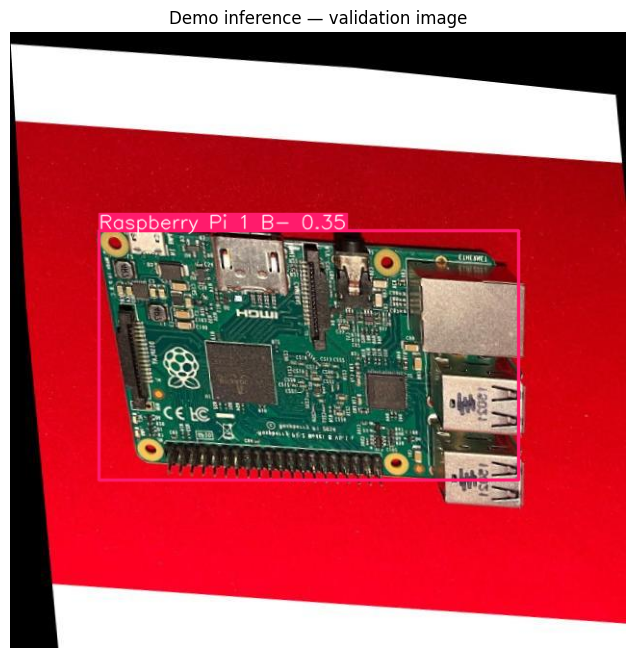

Image : valid_100__2B-22_jpg.rf.e645b9ddb1a583e892ffd48757748d4c.jpg
Boxes : 1


In [7]:
best_ssl = os.path.join(ssl_dir, "weights", "best.pt")
demo_model = YOLO(best_ssl)

demo_img = sorted(glob.glob(os.path.join(yolo_root, "images", "val", "*")))[0]
res = demo_model.predict(demo_img, imgsz=IMGSZ, conf=CONF, iou=IOU_NMS, device=device, verbose=False)[0]

plt.figure(figsize=(8, 8))
plt.imshow(res.plot()[:, :, ::-1])
plt.title("Demo inference — validation image")
plt.axis("off")
plt.show()

print("Image :", os.path.basename(demo_img))
print("Boxes :", len(res.boxes))

## Baselines, rho = 0.20

In [8]:
rand_dir = "/kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-baseline/base_random"
coco_dir = "/kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-baseline/base_coco"

print("Reusing baseline checkpoints (no retraining):")
print("Random-init dir:", rand_dir)
print("COCO-pretrained dir:", coco_dir)

Reusing baseline checkpoints (no retraining):
Random-init dir: /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-baseline/base_random
COCO-pretrained dir: /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-baseline/base_coco


## Evaluation — validation + test

In [9]:
def evaluate(run_dir, tag):
    w = os.path.join(run_dir, "weights", "best.pt")
    m = YOLO(w)
    rows = {}
    for split in ["val", "test"]:
        r = m.val(data=DATA_YAML, split=split, imgsz=IMGSZ, batch=BATCH,
                  conf=0.001, iou=IOU_NMS, device=device,
                  project=working_dir, name=f"{tag}_{split}_eval",
                  exist_ok=True, plots=True, verbose=False)
        rows[split] = dict(
            precision=float(r.box.mp), recall=float(r.box.mr),
            mAP50=float(r.box.map50), mAP50_95=float(r.box.map),
            save_dir=str(r.save_dir),
        )
    return rows

results = {
    "SimCLR (SSL init)": evaluate(ssl_dir,  "simclr"),
    "Random init":       evaluate(rand_dir, "randinit"),
    "COCO-pretrained":   evaluate(coco_dir, "coco"),
}

print(f"\n{'initialisation':<22}{'split':<7}{'P':>8}{'R':>8}{'mAP50':>9}{'mAP50-95':>11}")
for name, rows in results.items():
    for split, v in rows.items():
        print(f"{name:<22}{split:<7}{v['precision']:>8.3f}{v['recall']:>8.3f}"
              f"{v['mAP50']:>9.3f}{v['mAP50_95']:>11.3f}")

Ultralytics 8.4.143 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO12s summary (fused): 159 layers, 9,243,264 parameters, 0 gradients, 23.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 54.5±21.1 MB/s, size: 43.6 KB)
val: Scanning /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition/yolo_rho20/labels/val... 311 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 311/311 1.1Kit/s 0.3s
WARNING ⚠️ val: Cache directory /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition/yolo_rho20/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 3.4it/s 6.0s
                   all        311        322      0.792      0.809      0.841      0.762
Speed: 1.6ms preprocess, 13.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/simclr_val_eval
Ultralytics 8.4.143 🚀 Python-3.12.13 torch-2.10.0+cu

## Qualitative predictions

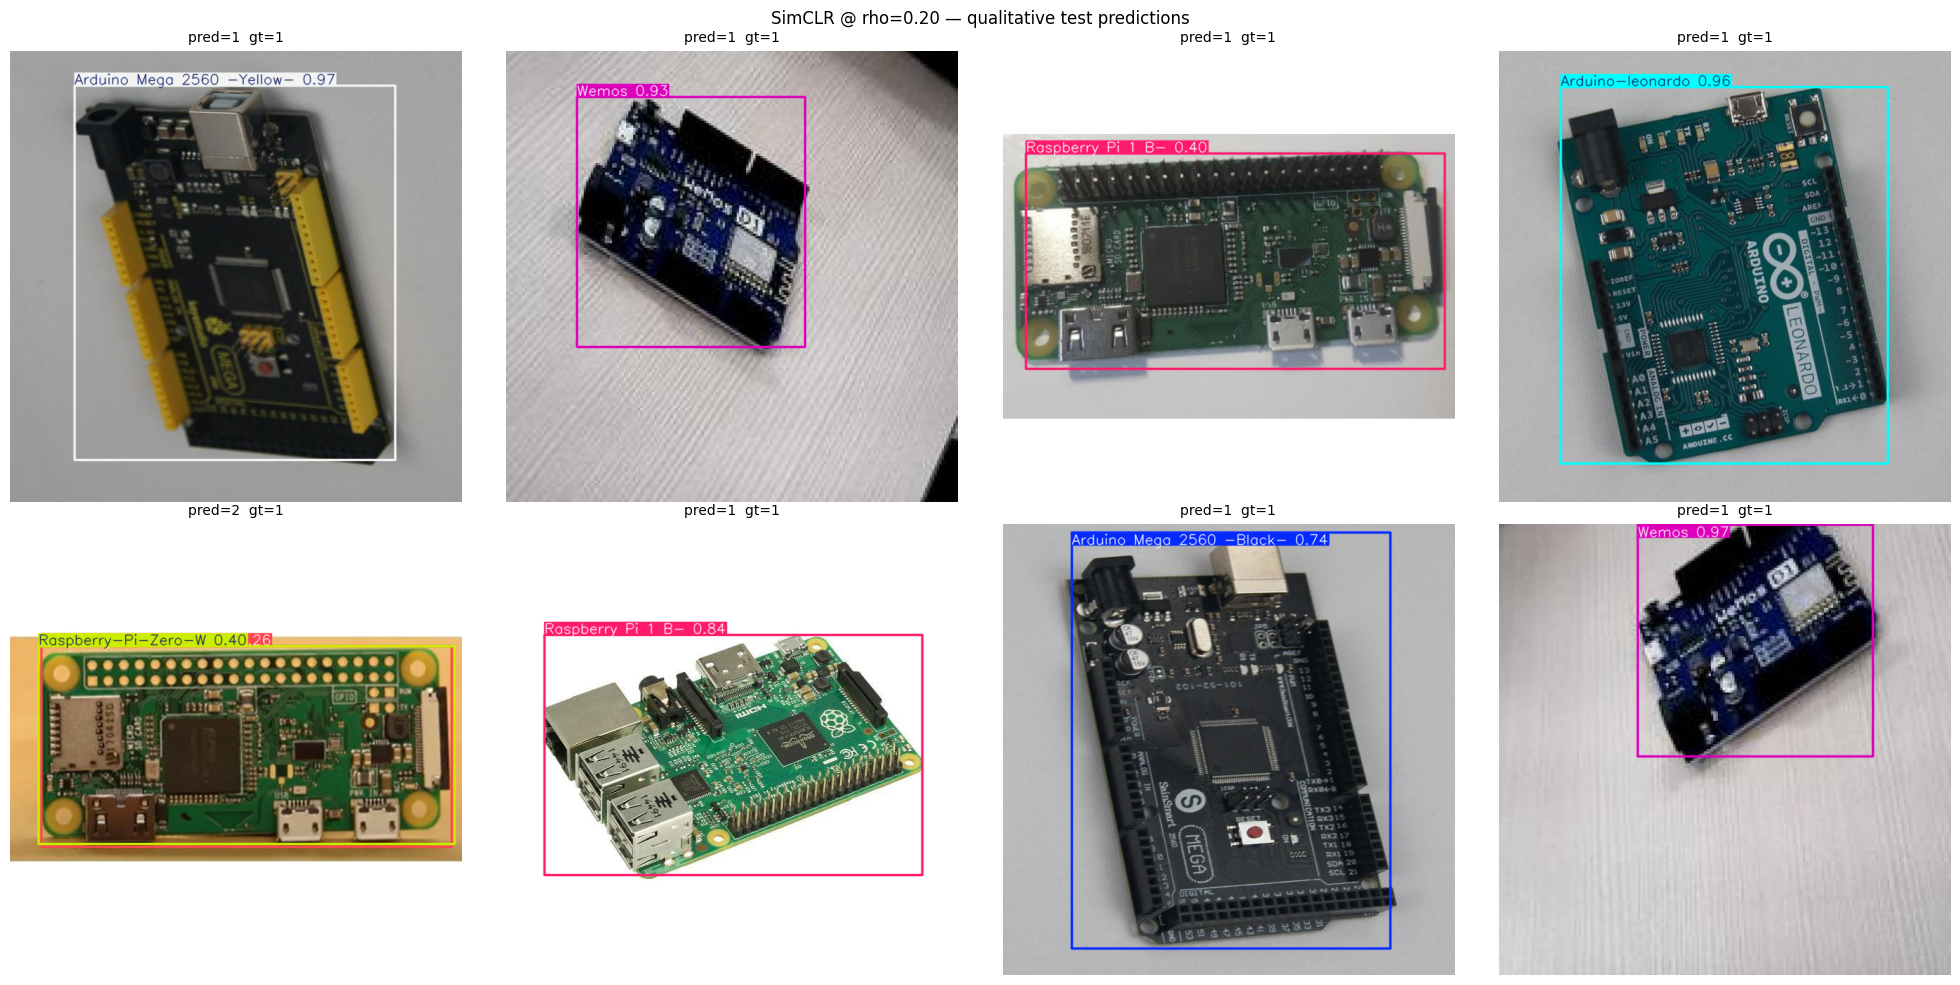

In [10]:
qual_model = YOLO(best_ssl)
test_imgs = sorted(glob.glob(os.path.join(yolo_root, "images", "test", "*")))
random.Random(SEED).shuffle(test_imgs)
picks = test_imgs[:8]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, p in zip(axes.ravel(), picks):
    r = qual_model.predict(p, imgsz=IMGSZ, conf=CONF, iou=IOU_NMS, device=device, verbose=False)[0]
    n_gt = 0
    lp = os.path.join(yolo_root, "labels", "test", os.path.splitext(os.path.basename(p))[0] + ".txt")
    if os.path.exists(lp):
        with open(lp) as fh:
            n_gt = sum(1 for line in fh if line.strip())
    ax.imshow(r.plot()[:, :, ::-1])
    ax.set_title(f"pred={len(r.boxes)}  gt={n_gt}", fontsize=10)
    ax.axis("off")

plt.suptitle("SimCLR @ rho=0.20 — qualitative test predictions")
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "simclr_qualitative.png"), dpi=150)
plt.show()

## Save Results

In [11]:
import pandas as pd

rows = []
for label, key in [("random_init",     "Random init"),
                   ("coco_pretrained", "COCO-pretrained"),
                   ("simclr",          "SimCLR (SSL init)")]:
    v = results[key]["test"]
    rows.append({
        "model":     label,
        "rho":       RHO,
        "precision": v["precision"],
        "recall":    v["recall"],
        "map50":     v["mAP50"],
        "map50_95":  v["mAP50_95"],
    })

df = pd.DataFrame(rows)
print(df)

csv_path = os.path.join(working_dir, "simclr_result.csv")
df.to_csv(csv_path, index=False)
print()
print("Saved:", csv_path)

             model  rho  precision    recall     map50  map50_95
0      random_init  0.2   0.707130  0.783251  0.790748  0.725699
1  coco_pretrained  0.2   0.898948  0.885518  0.928631  0.895740
2           simclr  0.2   0.759724  0.764839  0.816350  0.740758

Saved: /kaggle/working/simclr_result.csv
